In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols

from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
df = pd.read_csv("../data/processed/listings_cleaned.csv")

print(df.shape)

df.head()

(5864, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_clean
0,27886,https://www.airbnb.com/rooms/27886,20250911031321,2025-09-11,city scrape,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,...,4.90,4.78,0363 974D 4986 7411 88D8,f,1,0,1,0,1.87,132.0
1,28871,https://www.airbnb.com/rooms/28871,20250911031321,2025-09-11,city scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,...,4.93,4.83,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,3.99,89.0
2,29051,https://www.airbnb.com/rooms/29051,20250911031321,2025-09-11,city scrape,Comfortable single / double room,This room can also be rented as a single or a ...,the street is quite lively especially on weeke...,https://a0.muscache.com/pictures/162009/bd6be2...,124245,...,4.87,4.79,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,4.81,61.0
3,49552,https://www.airbnb.com/rooms/49552,20250911031321,2025-09-11,city scrape,Multatuli Luxury Guest Suite in top location,Stylish & spacious 60m2 guest suite in Amsterd...,You will find yourself in a quiet side street ...,https://a0.muscache.com/pictures/a6d6d2ee-3196...,225987,...,4.98,4.78,0363 576A D827 5085 6B83,f,1,1,0,0,3.36,322.0
4,50263,https://www.airbnb.com/rooms/50263,20250911031321,2025-09-11,city scrape,Central de Lux 2 bedrooms (4p) apt 125 sqm,A beautiful 'De Lux' 125 sqm apartment for 4 a...,The house is located in a green park where no...,https://a0.muscache.com/pictures/677876/7cb949...,230246,...,4.66,4.75,0363 7F3D 0BAE 28C8 C7D2,f,1,1,0,0,0.97,457.0


In [3]:
# top 5 neighbourhoods
top_neighbourhoods = (
    df["neighbourhood_cleansed"]
    .value_counts()
    .head(5)
    .index
)

df_anova = df[
    df["neighbourhood_cleansed"].isin(top_neighbourhoods)
]

df_anova["neighbourhood_cleansed"].value_counts()

neighbourhood_cleansed
De Baarsjes - Oud-West     992
Centrum-West               769
De Pijp - Rivierenbuurt    649
Centrum-Oost               580
Zuid                       435
Name: count, dtype: int64

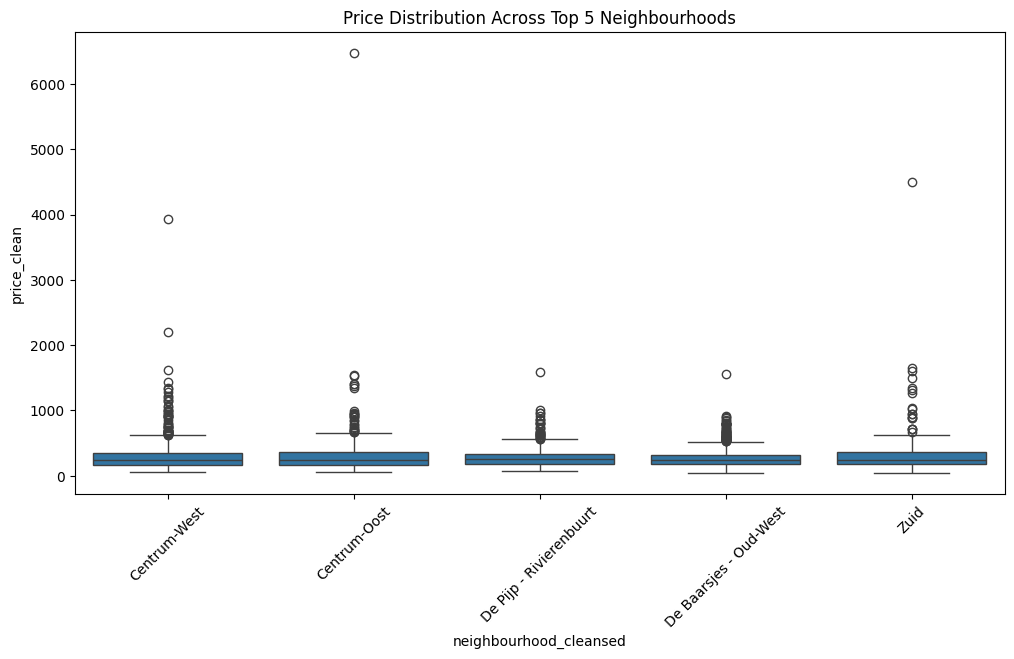

In [4]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="neighbourhood_cleansed",
    y="price_clean",
    data=df_anova
)

plt.xticks(rotation=45)

plt.title("Price Distribution Across Top 5 Neighbourhoods")

plt.show()

In [6]:
# shapiro -wilk
sample_prices = df_anova["price_clean"].sample(
    min(500, len(df_anova))
)

stat, p = stats.shapiro(sample_prices)

print("Shapiro Statistic =", stat)
print("p-value =", p)

if p > 0.05:
    print("Data approximately normal")
else:
    print("Data not normally distributed")

Shapiro Statistic = 0.48536646808156825
p-value = 1.4922900250570027e-35
Data not normally distributed


In [8]:
groups = []

for area in top_neighbourhoods:
    groups.append(
        df_anova[
            df_anova["neighbourhood_cleansed"] == area
        ]["price_clean"]
    )

stat, p = stats.levene(*groups)

print("Levene Statistic =", stat)
print("p-value =", p)

if p > 0.05:
    print("Equal variances assumed")
else:
    print("Variances differ")

Levene Statistic = 7.356231553965966
p-value = 6.769402433827127e-06
Variances differ


In [9]:
model = ols(
    'price_clean ~ C(neighbourhood_cleansed)',
    data=df_anova
).fit()

anova_table = sm.stats.anova_lm(
    model,
    typ=2
)

print(anova_table)

                                 sum_sq      df        F    PR(>F)
C(neighbourhood_cleansed)  8.860605e+05     4.0  4.17808  0.002234
Residual                   1.813229e+08  3420.0      NaN       NaN


In [11]:
eta_squared = (
    anova_table["sum_sq"][0]
    /
    anova_table["sum_sq"].sum()
)

print("Eta Squared =", eta_squared)

if eta_squared < 0.06:
    effect = "Small"
elif eta_squared < 0.14:
    effect = "Medium"
else:
    effect = "Large"

print(f"Effect Size: {effect}")

Eta Squared = 0.00486288050930313
Effect Size: Small


C:\Users\Ravindu Aluvihare\AppData\Local\Temp\ipykernel_14456\2663527969.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  anova_table["sum_sq"][0]


In [12]:
tukey = pairwise_tukeyhsd(
    endog=df_anova["price_clean"],
    groups=df_anova["neighbourhood_cleansed"],
    alpha=0.05
)

print(tukey)

                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
         group1                  group2         meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------------------
           Centrum-Oost            Centrum-West  -4.4368 0.9968 -38.9974 30.1239  False
           Centrum-Oost  De Baarsjes - Oud-West -36.4419 0.0209   -69.29 -3.5938   True
           Centrum-Oost De Pijp - Rivierenbuurt -27.2588 0.2326  -63.167  8.6494  False
           Centrum-Oost                    Zuid   1.8598 0.9999 -37.9994 41.7189  False
           Centrum-West  De Baarsjes - Oud-West -32.0051 0.0314 -62.1987 -1.8116   True
           Centrum-West De Pijp - Rivierenbuurt -22.8221 0.3397 -56.3191  10.675  False
           Centrum-West                    Zuid   6.2965 0.9911  -31.405 43.9981  False
 De Baarsjes - Oud-West De Pijp - Rivierenbuurt   9.1831 0.9336  -22.544 40.9101  False
 De Baarsjes - Oud-West         

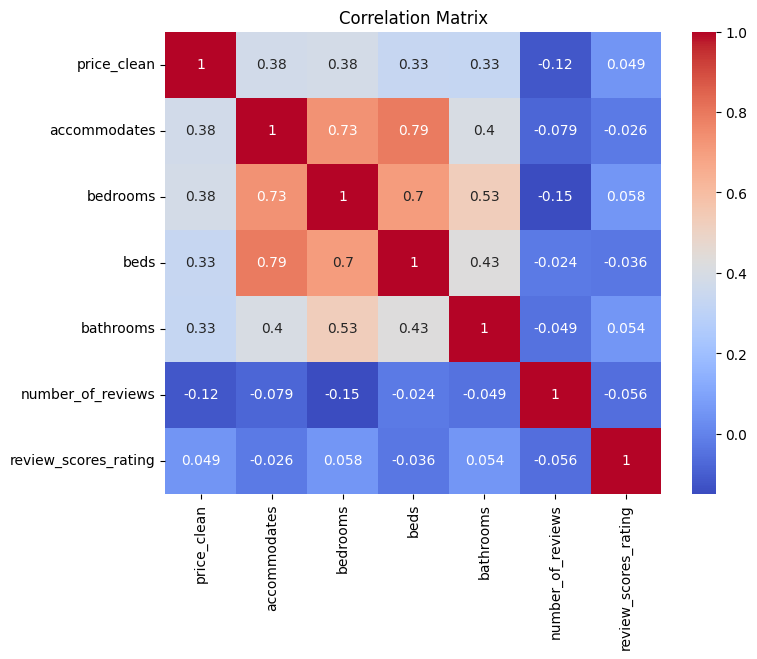

In [13]:
corr_cols = [
    "price_clean",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "review_scores_rating"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()